In [1]:
# Imports
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Function to calculate percentage based on obs
def calculate_percentage(subset, feature):
    positive_cells = (subset.obs[feature] > 0).sum()
    return (positive_cells / subset.n_obs) * 100    

# Function to calculate percentage based on expression data (for CDKN2A)
def calculate_percentage_expression(subset, gene_name):
    if gene_name in subset.var_names:
        gene_expression = subset[:, gene_name].X
        positive_cells = (gene_expression > 0).sum()
        return (positive_cells / subset.n_obs) * 100
    else:
        raise KeyError(f"{gene_name} not found in var_names")

# Function to calculate average expression
def calculate_average_expression(subset, gene_name):
    if gene_name in subset.var_names:
        gene_expression = subset[:, gene_name].X
        return gene_expression.mean()
    else:
        raise KeyError(f"{gene_name} not found in var_names")
# Function to calculate standard error for binary presence (percentages)
def calculate_standard_error(subset, feature):
    positive_cells = (subset.obs[feature] > 0).sum()
    total_cells = subset.n_obs
    
    if total_cells == 0:
        return 0  # Avoid division by zero
    
    p = positive_cells / total_cells  # Proportion of positive cells
    se = np.sqrt(p * (1 - p) / total_cells) * 100  # Convert to percentage scale
    print(feature)
    return se


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scanpy==1.10.3 anndata==0.10.9 umap==0.5.6 numpy==1.23.5 scipy==1.9.3 pandas==1.5.2 scikit-learn==1.5.2 statsmodels==0.14.4 pynndescent==0.5.13


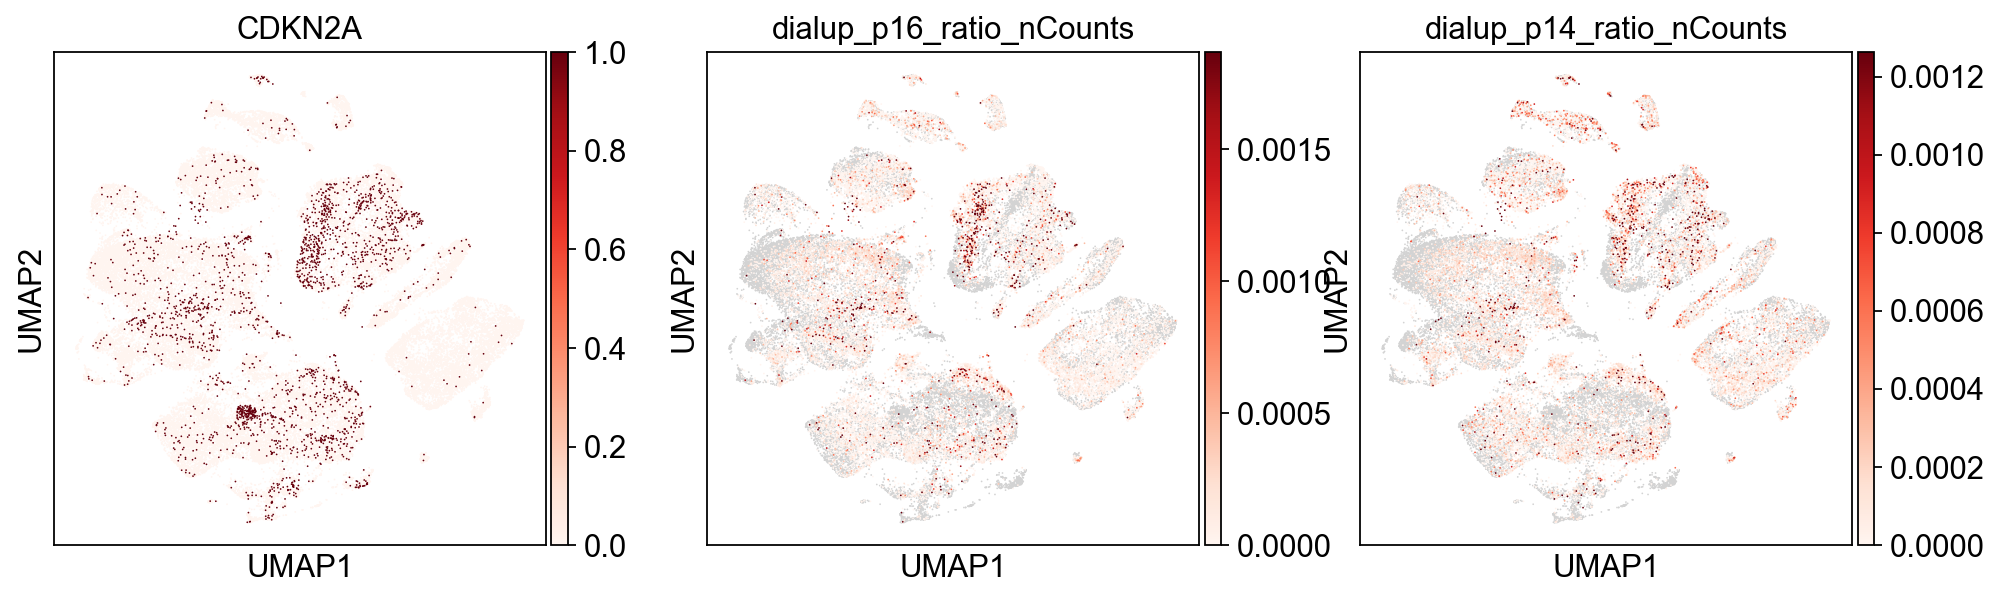

In [4]:
sc.settings.verbosity = 3    
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

adata=sc.read('Figure1B-2A_allCells_SingleCellExperiment_converted_to_Seurat_then_to_h5ad_withCoords_with_p14_p16_remap.h5ad')
a1=pd.read_csv('dialup_brugge/BRCA1-C_S9_p16_p14_per_cell.tsv', sep='\t', index_col=0)
a1.index='Human-BRCA1-C_'+a1.index

a2=pd.read_csv('dialup_brugge/BRCA1-D_S10_p16_p14_per_cell.tsv', sep='\t', index_col=0)
a2.index='Human-BRCA1-D_'+a2.index

a3=pd.read_csv('dialup_brugge/BRCA1-H_S6_p16_p14_per_cell.tsv', sep='\t', index_col=0)
a3.index='Human-BRCA1-H_'+a3.index

a4=pd.read_csv('dialup_brugge/BRCA2-B_S11_p16_p14_per_cell.tsv', sep='\t', index_col=0)
a4.index='Human-BRCA2-B_'+a4.index

a5=pd.read_csv('dialup_brugge/BRCA2-D_S3_p16_p14_per_cell.tsv', sep='\t', index_col=0)
a5.index='Human-BRCA2-D_'+a5.index

a6=pd.read_csv('dialup_brugge/BRCA2-E_S7_p16_p14_per_cell.tsv', sep='\t', index_col=0)
a6.index='Human-BRCA2-E_'+a6.index

a7=pd.read_csv('dialup_brugge/Human-B2-1_S8_p16_p14_per_cell.tsv', sep='\t', index_col=0)
#B2-1 is BRCA2-A in the paper
a7.index='Human-BRCA2-A_'+a7.index

a8=pd.read_csv('dialup_brugge/Human-WT-1_S2_p16_p14_per_cell.tsv', sep='\t', index_col=0)
#WT-1 is WT-A in the paper
a8.index='Human-WT-A_'+a8.index

a9=pd.read_csv('dialup_brugge/WT-C_S4_p16_p14_per_cell.tsv', sep='\t', index_col=0)
a9.index='Human-WT-C_'+a9.index
a10=pd.read_csv('dialup_brugge/WT-D_S5_p16_p14_per_cell.tsv', sep='\t', index_col=0)
a10.index='Human-WT-D_'+a10.index

to_concat = [a1, a2, a3, a4, a5, a6, a7, a8, a9, a10]
dialup = pd.concat(to_concat)
dialup=dialup.rename(columns={"p16": "dialup_p16", "p14": "dialup_p14"})
idx = adata.obs.index.intersection(dialup.index)
dialup2=dialup.loc[idx]
dupls=dialup2.index[dialup2.index.duplicated()]
dialup2.loc[dupls]['dialup_p16'][dialup2.loc[dupls]['dialup_p16']>0]
dialup2.loc[dupls]['dialup_p14'][dialup2.loc[dupls]['dialup_p14']>0]
dialup3 = dialup2[~dialup2.index.duplicated(keep='first')]

adata.obs['dialup_p16']=dialup3['dialup_p16']
adata.obs['dialup_p14']=dialup3['dialup_p14']
adata.obs['dialup_p16_ratio_nCounts']=adata.obs['dialup_p16']/adata.obs['nCount_RNA']
adata.obs['dialup_p14_ratio_nCounts']=adata.obs['dialup_p14']/adata.obs['nCount_RNA']
sc.pl.umap(adata, color=['CDKN2A', 'dialup_p16_ratio_nCounts', 'dialup_p14_ratio_nCounts'], color_map='Reds', vmax='p98.5')


In [5]:
# only samples that we did dialup on
sample_mask = ~adata.obs.index.str.contains("BRCA1-B|BRCA1-G|BRCA1-E|BRCA2-C|BRCA2-F|WT-B")
# get rid of "doublet" cluster
doublet_mask = adata.obs['cellSubtype'] != 'doublet'

combined_mask = sample_mask & doublet_mask

adata_filtered = adata[combined_mask, :]
adata_filtered = adata_filtered.copy()  # Ensure it's a full AnnData object
adata_filtered.obs["donor"] = adata_filtered.obs["sampleID2"]
# Define mapping from subcell types to broad cell types
cell_type_mapping = {
    "F1": "Fibroblast", "F2": "Fibroblast", "F3": "Fibroblast",
    "BL": "Alveolar", "AP": "Alveolar",
    "BAP1": "Basal", "BAP2": "Basal", "BAP3": "Basal",
    "LE": "Vascular", "PE": "Vascular", "VE": "Vascular",
    "M": "Immune", "NK": "Immune", "P": "Immune", "T": "Immune", "B": "Immune",
    "HSa": "Hormone Sensing", "HSb": "Hormone Sensing"
}


In [25]:
# Ensure 'cellSubtype' exists and map to broad CellType
adata_filtered.obs["CellType"] = adata_filtered.obs["cellSubtype"].map(cell_type_mapping)

adata_filtered.write_h5ad('Brugge_dialup_filtered.h5ad')
# Create a DataFrame from the computed ratios
df_ratios = adata_filtered.obs[['cellSubtype', 'dialup_p16_ratio_nCounts', 'dialup_p14_ratio_nCounts']]
df_expression = adata_filtered[:, adata.var.index.isin(['CDKN2A', 'CDKN2B', 'CDKN2B-AS1', 'MTAP'])].to_df()
df_expression["cellSubtype"] = adata_filtered.obs["cellSubtype"].values  # Add CellType column

In [26]:
# Save to a CSV file
df_ratios.to_csv("dialup_ratios.csv", index=True)
df_expression.to_csv("expression_ratios.csv", index=True)


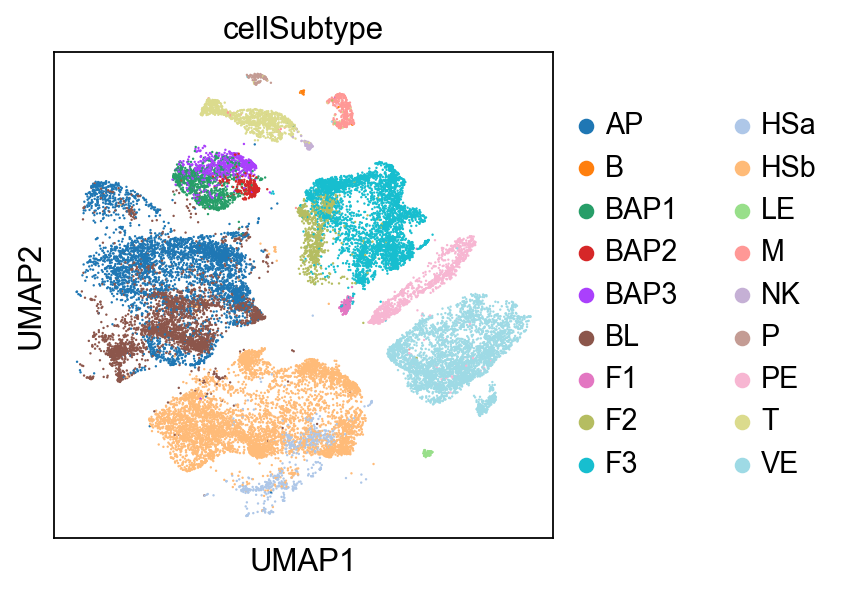

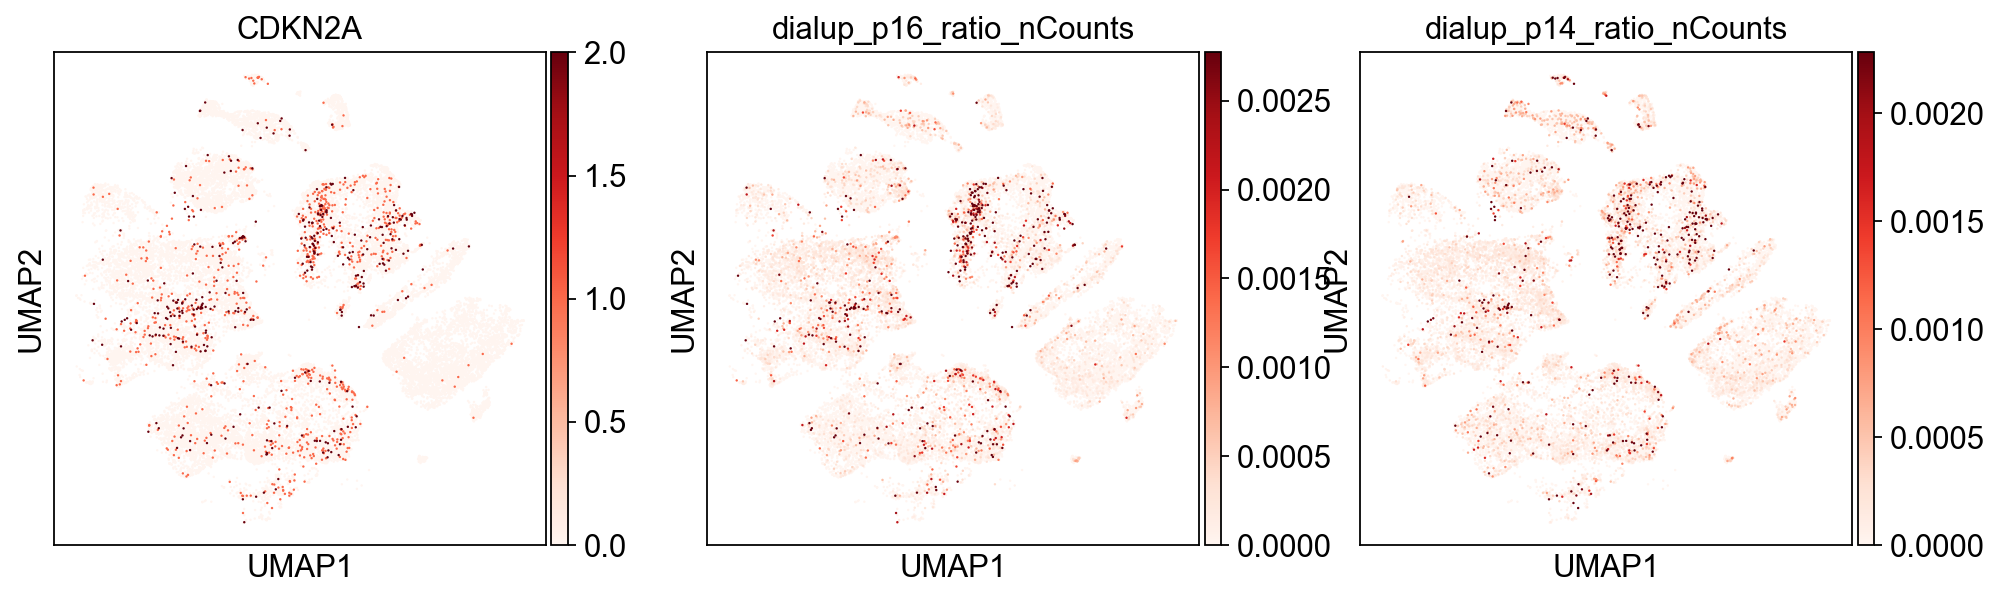

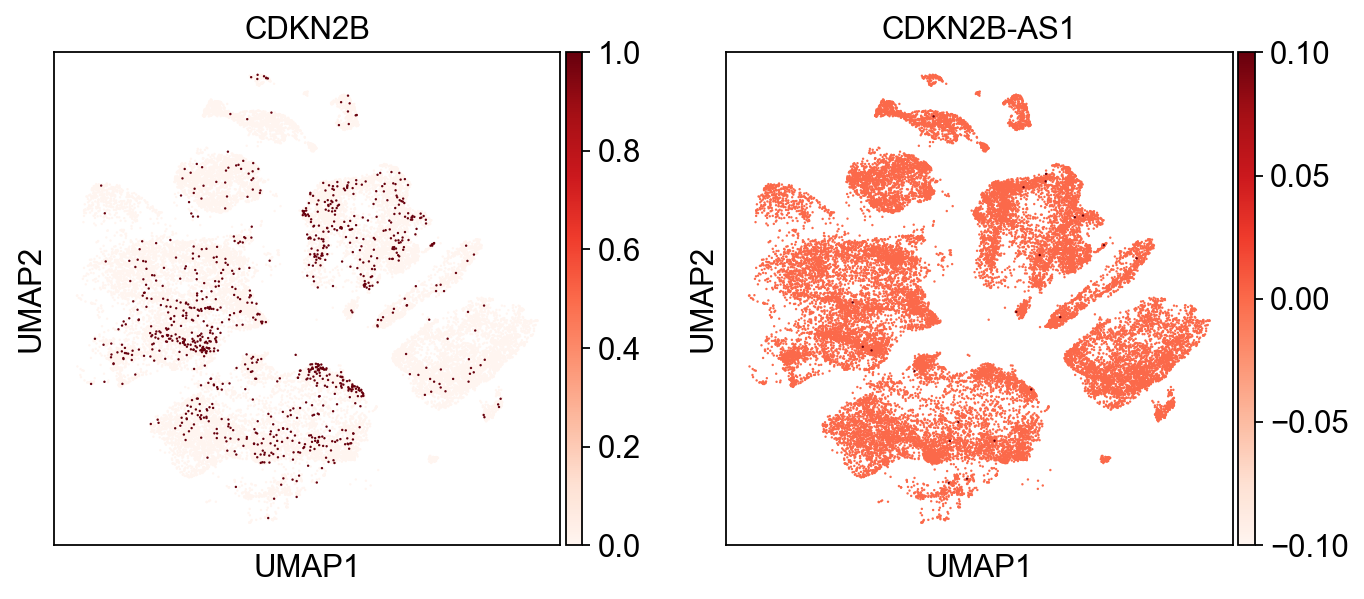

In [7]:
sc.pl.umap(adata_filtered, color=['cellSubtype'], save='_cellSubtype.svg')
sc.pl.umap(adata_filtered, color=['CDKN2A', 'dialup_p16_ratio_nCounts', 'dialup_p14_ratio_nCounts'],  color_map='Reds', vmax="p99", save='_ratios1.svg')
sc.pl.umap(adata_filtered, color=['CDKN2B', 'CDKN2B-AS1'],  vmax="p99", color_map='Reds', save='_ratios2.svg')


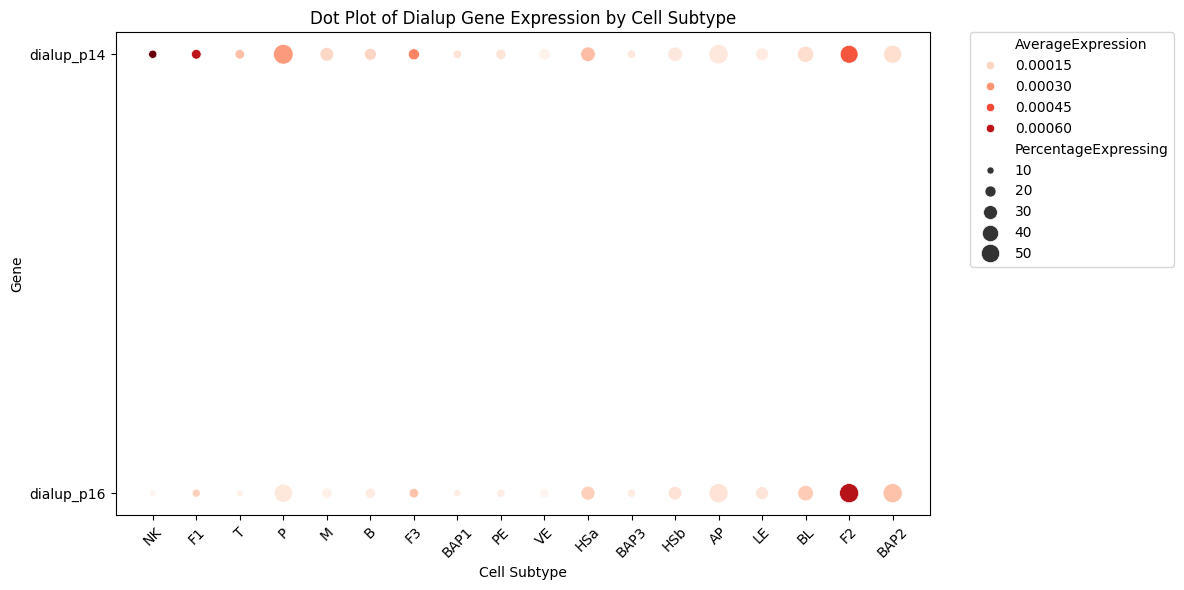

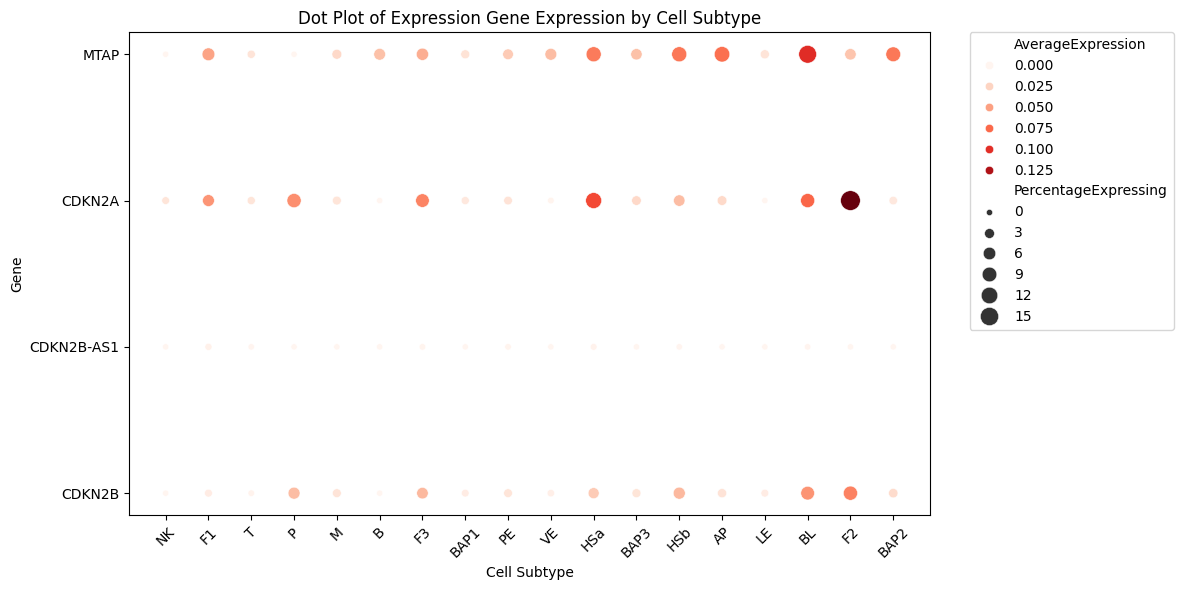

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
dialup_df = pd.read_csv("dialup_ratios.csv")
expr_df = pd.read_csv("expression_ratios.csv")

# Rename gene columns for easier reference in dialup dataset
dialup_df.rename(columns={"dialup_p16_ratio_nCounts": "dialup_p16", "dialup_p14_ratio_nCounts": "dialup_p14"}, inplace=True)

# Compute mean expression per cellSubtype for dialup data
dialup_mean = dialup_df.groupby("cellSubtype")[["dialup_p14", "dialup_p16"]].mean().reset_index()

# Compute percentage of cells expressing each gene in dialup data
dialup_percent = dialup_df.groupby("cellSubtype")[["dialup_p14", "dialup_p16"]].apply(lambda x: (x > 0).mean() * 100).reset_index()

# Compute p14/p16 Ratio and sort cell subtypes
dialup_mean["p14_p16_ratio"] = dialup_mean["dialup_p14"] / dialup_mean["dialup_p16"]
sorted_subtypes = dialup_mean.sort_values("p14_p16_ratio", ascending=False)["cellSubtype"].tolist()

# Melt dialup data for plotting
dialup_melted = dialup_mean.melt(id_vars=["cellSubtype"], var_name="Gene", value_name="AverageExpression")
dialup_percent_melted = dialup_percent.melt(id_vars=["cellSubtype"], var_name="Gene", value_name="PercentageExpressing")

# Ensure cellSubtype is an ordered category
dialup_melted["cellSubtype"] = pd.Categorical(dialup_melted["cellSubtype"], categories=sorted_subtypes, ordered=True)
dialup_percent_melted["cellSubtype"] = pd.Categorical(dialup_percent_melted["cellSubtype"], categories=sorted_subtypes, ordered=True)

# Merge percent expressing into dialup dataframe
dialup_plot_data = dialup_melted.merge(dialup_percent_melted, on=["cellSubtype", "Gene"])

# Plot Dialup Data
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=dialup_plot_data,
    x="cellSubtype", y="Gene",
    size="PercentageExpressing", sizes=(20, 200),  # Size by % Expressing
    hue="AverageExpression", palette="Reds",  # Color by Mean Expression
    legend="brief"
)
plt.title("Dot Plot of Dialup Gene Expression by Cell Subtype")
plt.xlabel("Cell Subtype")
plt.ylabel("Gene")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(False)
plt.tight_layout()
plt.show()

### Processing Expression Data ###
# Compute mean expression per cellSubtype for expression data
expr_genes = ["MTAP", "CDKN2A", "CDKN2B-AS1", "CDKN2B"]
expr_mean = expr_df.groupby("cellSubtype")[expr_genes].mean().reset_index()

# Compute percentage of cells expressing each gene in expression data
expr_percent = expr_df.groupby("cellSubtype")[expr_genes].apply(lambda x: (x > 0).mean() * 100).reset_index()

# Melt expression data for plotting
expr_melted = expr_mean.melt(id_vars=["cellSubtype"], var_name="Gene", value_name="AverageExpression")
expr_percent_melted = expr_percent.melt(id_vars=["cellSubtype"], var_name="Gene", value_name="PercentageExpressing")

# Use the same ordered cellSubtype categories as dialup data
expr_melted["cellSubtype"] = pd.Categorical(expr_melted["cellSubtype"], categories=sorted_subtypes, ordered=True)
expr_percent_melted["cellSubtype"] = pd.Categorical(expr_percent_melted["cellSubtype"], categories=sorted_subtypes, ordered=True)

# Merge percent expressing into expression dataframe
expr_plot_data = expr_melted.merge(expr_percent_melted, on=["cellSubtype", "Gene"])

# Plot Expression Data
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=expr_plot_data,
    x="cellSubtype", y="Gene",
    size="PercentageExpressing", sizes=(20, 200),
    hue="AverageExpression", palette="Reds",
    legend="brief"
)
plt.title("Dot Plot of Expression Gene Expression by Cell Subtype")
plt.xlabel("Cell Subtype")
plt.ylabel("Gene")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(False)
plt.tight_layout()

plt.savefig("dot_plot_2.svg", format="svg")
plt.show()
